# FRC Match Metrics
Displays the results of a FRC match in a series of charts

## Setup
In your virtual environment, install pandas and matplotlib: 
  `pip install pandas matplotlib`
* If you are using VS Code, it should ask you to install the IPython extensions.
* If this next cell runs with no errors, you are all set.

In [14]:
import util
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

## Functions to get Team and Event names
Some parts of this notebook depend on a team you are interested in.  Other parts of this notebook need to look up the team name.  This section defines a function to look up the team name.  Same things for event name.

In [15]:
def get_team_name(team_id):
    url = f'https://www.thebluealliance.com/api/v3/team/{team_id}'
    return util.call_tba_api(url).json()['nickname']

def get_event_name(event_id):
    url = f'https://www.thebluealliance.com/api/v3/event/{EVENT_KEY}/simple'
    resp = util.call_tba_api(url).json()
    return str(resp['year']) + ' ' + resp['name']

## Default Team and Event

In [16]:
TEAM = 'frc1714'
EVENT_KEY = '2025mndu'

TEAM_NAME = get_team_name(TEAM)
EVENT_NAME = get_event_name(EVENT_KEY)

print(TEAM_NAME, 'at', EVENT_NAME)

MORE Robotics at 2025 Lake Superior Regional


## Team Metrics at one Event
There are three special metrics from TBA at `/oprs`.  The other basic metrics are at `\rankings`.

In this section, we create a Pandas dataframe.  Think about it like a spreadsheet in memory.  There are a couple of techniques used here to best get the data out of the different JSON responses.
1. The OPR metrics are in a dictionary by team, so we can pull them into individual dataframes.
2. The other metrics are in an array by each team, so we have to:

    * Figure out what values they provide.
    * Create a dataframe with those headers
    * Loop through the teams and put the unlabeled values into an array. (I add a calculated one: ranking points)
    * Append that array to the dataframe
3. Then we merge the three dfs from 1 into 2.
4. We add the team name.  This is a pretty powerful syntax.  For each row, it calls a function using the team value and inserts the name value.

In [17]:
# Get calculated rankings
url = f'https://www.thebluealliance.com/api/v3/event/{EVENT_KEY}/oprs'
response = util.call_tba_api(url).json()

df_opr = pd.DataFrame.from_dict(response['oprs'], orient='index', columns=['opr'])
df_dpr = pd.DataFrame.from_dict(response['dprs'], orient='index', columns=['dpr'])
df_ccwm = pd.DataFrame.from_dict(response['ccwms'], orient='index', columns=['ccwm'])

# Get other rankings
url = f'https://www.thebluealliance.com/api/v3/event/{EVENT_KEY}/rankings'
response = util.call_tba_api(url).json()

# Find out what values they have and create a base dataframe
headers = ['team']
for x in response['sort_order_info']:
    headers.append(x['name'])
headers.append('Ranking Points')
df = pd.DataFrame(columns=headers)

# Loop through the teams and add a record with the team's ranking
for r in response['rankings']:
    record = [r['team_key']]
    for x in range(len(headers) - 2):
        record.append(r['sort_orders'][x])
    record.append(r['sort_orders'][0] * r['matches_played'])
    df.loc[len(df.index)] = record

# Merge the original metrics into our most recent dataframe
df = df.merge(df_opr, left_on='team', right_index=True)
df = df.merge(df_dpr, left_on='team', right_index=True)
df = df.merge(df_ccwm, left_on='team', right_index=True)

# Get team names
df['Name'] = df['team'].apply(get_team_name)

# Clean up variables we don't need
del df_ccwm, df_dpr, df_opr, url, response, r, record, x, headers

df

,team,Ranking Score,Avg Coop,Avg Match,Avg Auto,Avg Barge,Ranking Points,opr,dpr,ccwm,Name
0,frc876,4.78,0.33,123.67,17.89,16.44,43.02,60.055057,15.924672,44.130385,Thunder Robotics
1,frc2847,4.78,0.22,131.78,25.56,16.44,43.02,73.906004,31.385019,42.520985,The MegaHertz
2,frc1732,4.44,0.44,121.78,19.56,13.78,39.96,59.775991,18.515454,41.260538,Hilltopper Robotics
3,frc1619,4.44,0.22,128.00,22.44,15.78,39.96,65.173623,34.084200,31.089423,Up-A-Creek Robotics
4,frc6147,4.00,0.22,108.22,21.33,16.89,36.00,38.147662,15.276436,22.871227,Tonkabots
5,frc8422,3.56,0.33,115.33,14.00,18.44,32.04,47.916895,51.045152,-3.128256,Husky Howlers
6,frc4607,3.56,0.22,111.22,17.22,9.11,32.04,46.582711,36.335670,10.247041,C.I.S.
7,frc4656,3.56,0.11,87.00,14.00,20.67,32.04,28.465513,30.020801,-1.555288,Rock Solid Robotics
8,frc3197,3.44,0.22,118.22,16.22,10.00,30.96,57.064277,32.067900,24.996378,HexHounds
9,frc3100,3.44,0.00,103.89,17.00,10.67,30.96,39.724568,14.855081,24.869487,Lightning Turtles


## Function to Draw a Chart
This function draws a horizontal bar chart for the specified column.
Right now, it accesses "global" variables for `TEAM`, `TEAM_NAME` and `EVENT_NAME`.
You only need to run this cell once per session.

In [23]:
# Create a chart given a dataframe and other info
def print_chart(df, col, title, invert=False):
    # First, sort by the column we are interested in
    df = df.sort_values(by=col, ascending=invert, ignore_index=True) 

    # Get the figure and axis variables so we can configure it
    fig, ax = plt.subplots()

    # Create a horizontal bar chart with the data
    hbars = ax.barh(df['team'], df[col], align='center')

    # Highlight the team we are interested in
    i = df[df['team'] == TEAM].index.values[0]
    hbars[i].set_color('r')  

    # Turn off the labels - too noisy
    ax.get_yaxis().set_visible(False)

    # Make it descending - maybe pass this in...
    ax.invert_yaxis()

    # Get our score
    score = df[df['team'] == TEAM][col].values[0]

    team_loc = '#' + str(TEAM).replace('frc','') + ' ' + TEAM_NAME + ' at ' + EVENT_NAME + '\n'

    ax.set_title(team_loc  + title.replace('\n', f' = {score:.2f} (#{i + 1})\n'))
    plt.show()

    print(df[['team', col, 'Name']].iloc[:50])


## Print Charts

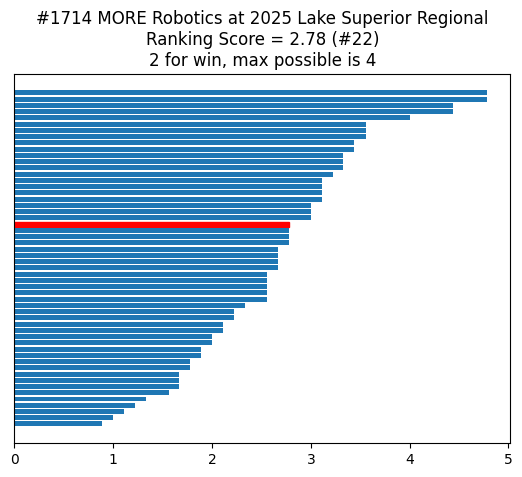

        team  Ranking Score                  Name
0     frc876           4.78      Thunder Robotics
1    frc2847           4.78         The MegaHertz
2    frc1732           4.44   Hilltopper Robotics
3    frc1619           4.44   Up-A-Creek Robotics
4    frc6147           4.00             Tonkabots
5    frc8422           3.56         Husky Howlers
6    frc4607           3.56                C.I.S.
7    frc4656           3.56   Rock Solid Robotics
8    frc3197           3.44             HexHounds
9    frc3100           3.44     Lightning Turtles
10   frc2143           3.33            Team Tobor
11   frc3293           3.33             OtterBots
12   frc6574           3.33           Ferradermis
13   frc2861           3.22        Infinity's End
14   frc3206           3.11        Royal T-Wrecks
15   frc4741           3.11              WingNuts
16   frc5653           3.11        Iron Mosquitos
17   frc4674           3.11             RoboJacks
18   frc1306           3.00            BadgerBOTS


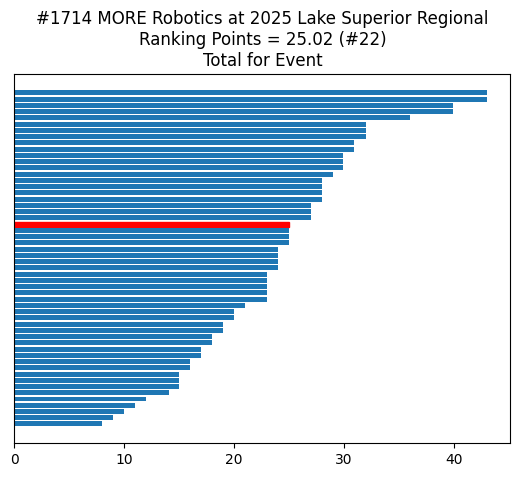

        team  Ranking Points                  Name
0     frc876           43.02      Thunder Robotics
1    frc2847           43.02         The MegaHertz
2    frc1732           39.96   Hilltopper Robotics
3    frc1619           39.96   Up-A-Creek Robotics
4    frc6147           36.00             Tonkabots
5    frc8422           32.04         Husky Howlers
6    frc4607           32.04                C.I.S.
7    frc4656           32.04   Rock Solid Robotics
8    frc3197           30.96             HexHounds
9    frc3100           30.96     Lightning Turtles
10   frc2143           29.97            Team Tobor
11   frc3293           29.97             OtterBots
12   frc6574           29.97           Ferradermis
13   frc2861           28.98        Infinity's End
14   frc3206           27.99        Royal T-Wrecks
15   frc4741           27.99              WingNuts
16   frc5653           27.99        Iron Mosquitos
17   frc4674           27.99             RoboJacks
18   frc1306           27.00   

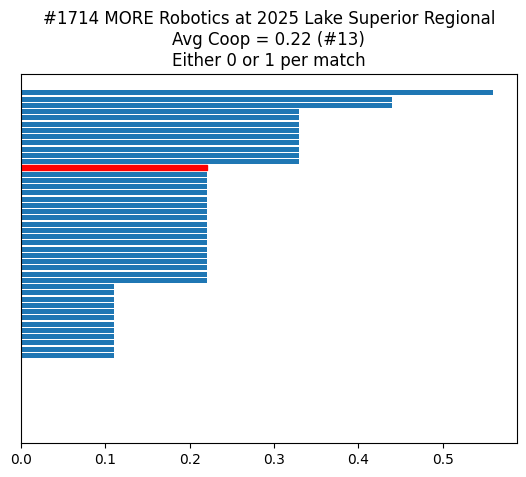

        team  Avg Coop                     Name
0    frc2526      0.56         Crimson Robotics
1    frc1732      0.44      Hilltopper Robotics
2    frc2654      0.44               Polar Rams
3     frc876      0.33         Thunder Robotics
4    frc3291      0.33               Au Pirates
5    frc3267      0.33         Mariner Robotics
6    frc4741      0.33                 WingNuts
7    frc3206      0.33           Royal T-Wrecks
8    frc2861      0.33           Infinity's End
9    frc2143      0.33               Team Tobor
10   frc5586      0.33             Bond Brigade
11   frc8422      0.33            Husky Howlers
12   frc1714      0.22            MORE Robotics
13   frc2847      0.22            The MegaHertz
14   frc4693      0.22         Talk Nerdy to Me
15   frc3277      0.22                  ProDigi
16   frc2181      0.22                    GEARS
17   frc9532      0.22               Messy Bees
18   frc5826      0.22            Avis Automata
19   frc6709      0.22             S.P.U

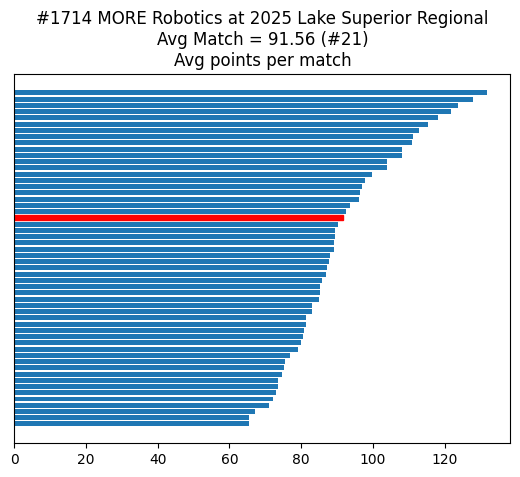

        team  Avg Match                  Name
0    frc2847     131.78         The MegaHertz
1    frc1619     128.00   Up-A-Creek Robotics
2     frc876     123.67      Thunder Robotics
3    frc1732     121.78   Hilltopper Robotics
4    frc3197     118.22             HexHounds
5    frc8422     115.33         Husky Howlers
6    frc5653     112.78        Iron Mosquitos
7    frc4607     111.22                C.I.S.
8    frc7028     111.00      Binary Battalion
9    frc6147     108.22             Tonkabots
10   frc2143     108.11            Team Tobor
11   frc2861     104.00        Infinity's End
12   frc3100     103.89     Lightning Turtles
13   frc3267      99.67      Mariner Robotics
14   frc3206      97.89        Royal T-Wrecks
15   frc3293      97.00             OtterBots
16   frc4741      96.33              WingNuts
17   frc2526      96.22      Crimson Robotics
18   frc1306      93.56            BadgerBOTS
19   frc3291      92.56            Au Pirates
20   frc1714      91.56         MO

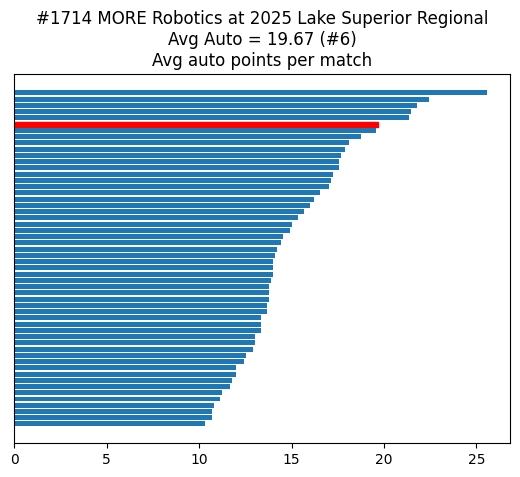

        team  Avg Auto                     Name
0    frc2847     25.56            The MegaHertz
1    frc1619     22.44      Up-A-Creek Robotics
2    frc5903     21.78                 ThorBots
3    frc7028     21.44         Binary Battalion
4    frc6147     21.33                Tonkabots
5    frc1714     19.67            MORE Robotics
6    frc1732     19.56      Hilltopper Robotics
7    frc6709     18.78             S.P.U.D. INC
8    frc2861     18.11           Infinity's End
9     frc876     17.89         Thunder Robotics
10   frc5653     17.67           Iron Mosquitos
11   frc7797     17.56          RipSaw Robotics
12   frc1306     17.56               BadgerBOTS
13   frc4607     17.22                   C.I.S.
14   frc5826     17.11            Avis Automata
15   frc3100     17.00        Lightning Turtles
16   frc7864     16.56     North Woods Robotics
17   frc3197     16.22                HexHounds
18   frc2846     16.00                FireBears
19   frc4181     15.67             Quack

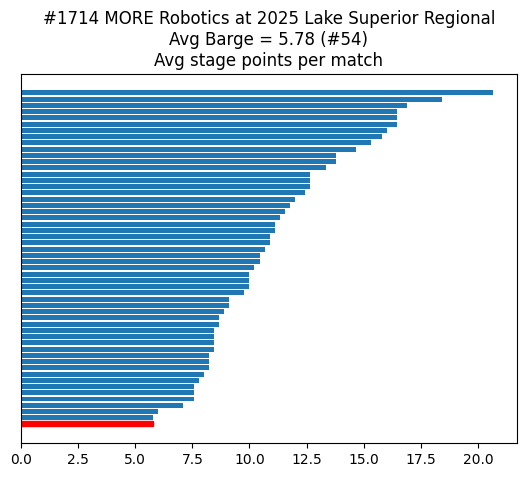

        team  Avg Barge                     Name
0    frc4656      20.67      Rock Solid Robotics
1    frc8422      18.44            Husky Howlers
2    frc6147      16.89                Tonkabots
3     frc876      16.44         Thunder Robotics
4    frc4674      16.44                RoboJacks
5    frc2847      16.44            The MegaHertz
6    frc3293      16.00                OtterBots
7    frc1619      15.78      Up-A-Creek Robotics
8    frc3294      15.33      Backwoods Engineers
9    frc7028      14.67         Binary Battalion
10   frc8122      13.78     Mechanical Mustaches
11   frc1732      13.78      Hilltopper Robotics
12   frc2861      13.33           Infinity's End
13   frc6574      12.67              Ferradermis
14   frc2654      12.67               Polar Rams
15   frc7797      12.67          RipSaw Robotics
16   frc5903      12.44                 ThorBots
17   frc2181      12.00                    GEARS
18   frc3381      11.78               Droid Rage
19   frc7864      11

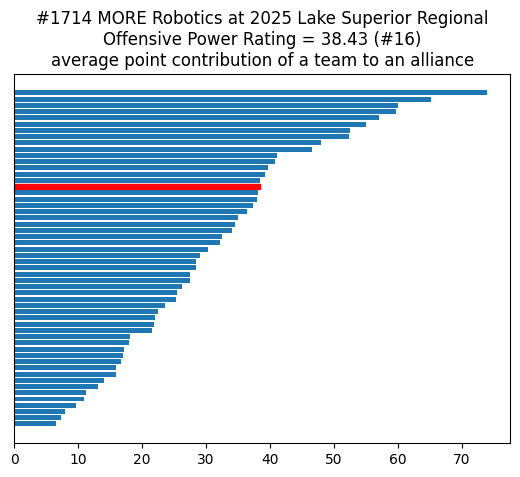

        team        opr                  Name
0    frc2847  73.906004         The MegaHertz
1    frc1619  65.173623   Up-A-Creek Robotics
2     frc876  60.055057      Thunder Robotics
3    frc1732  59.775991   Hilltopper Robotics
4    frc3197  57.064277             HexHounds
5    frc7028  54.965244      Binary Battalion
6    frc5653  52.482708        Iron Mosquitos
7    frc2861  52.299129        Infinity's End
8    frc8422  47.916895         Husky Howlers
9    frc4607  46.582711                C.I.S.
10   frc3206  41.107727        Royal T-Wrecks
11   frc3267  40.729453      Mariner Robotics
12   frc3100  39.724568     Lightning Turtles
13   frc2526  39.256034      Crimson Robotics
14   frc6709  38.503480          S.P.U.D. INC
15   frc1714  38.434445         MORE Robotics
16   frc6147  38.147662             Tonkabots
17   frc2143  37.998427            Team Tobor
18   frc4674  37.303265             RoboJacks
19   frc3293  36.334641             OtterBots
20   frc3277  34.944241           

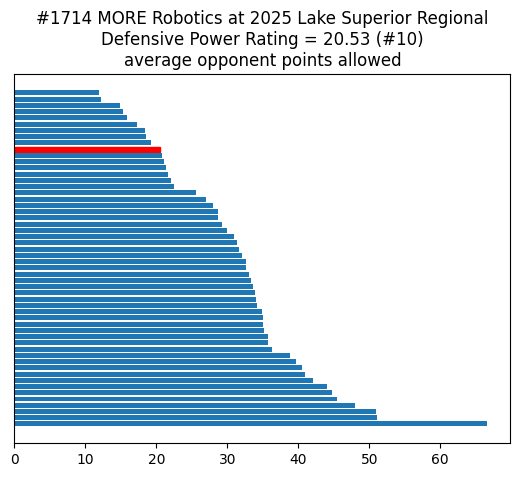

        team        dpr                     Name
0    frc2846  11.981787                FireBears
1    frc8516  12.223390                 Wired Up
2    frc3100  14.855081        Lightning Turtles
3    frc6147  15.276436                Tonkabots
4     frc876  15.924672         Thunder Robotics
5    frc6574  17.321656              Ferradermis
6    frc4674  18.403201                RoboJacks
7    frc1732  18.515454      Hilltopper Robotics
8    frc3277  19.189132                  ProDigi
9    frc1714  20.526079            MORE Robotics
10   frc6381  20.801524      Red Raider Robotics
11   frc7864  21.100885     North Woods Robotics
12   frc1306  21.372609               BadgerBOTS
13   frc2654  21.586837               Polar Rams
14   frc6217  22.123247                Bomb-Botz
15   frc3293  22.480946                OtterBots
16   frc9532  25.551829               Messy Bees
17   frc4011  26.933620               BANANABOTS
18   frc4181  27.933567             Quack Attack
19   frc2181  28.628

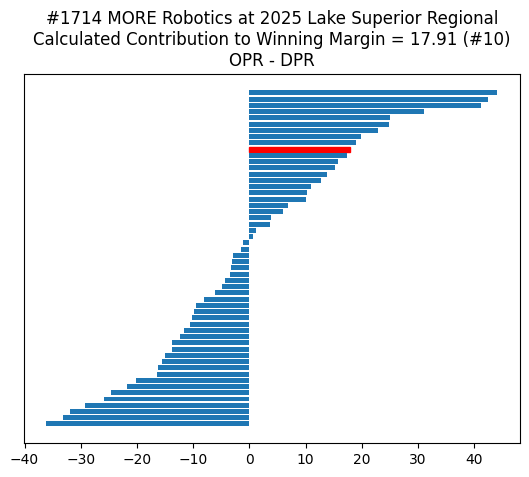

       team       ccwm                  Name
0    frc876  44.130385      Thunder Robotics
1   frc2847  42.520985         The MegaHertz
2   frc1732  41.260538   Hilltopper Robotics
3   frc1619  31.089423   Up-A-Creek Robotics
4   frc3197  24.996378             HexHounds
5   frc3100  24.869487     Lightning Turtles
6   frc6147  22.871227             Tonkabots
7   frc5653  19.899740        Iron Mosquitos
8   frc4674  18.900064             RoboJacks
9   frc1714  17.908366         MORE Robotics
10  frc2861  17.385347        Infinity's End
11  frc3277  15.755109               ProDigi
12  frc8516  15.206268              Wired Up
13  frc3293  13.853695             OtterBots
14  frc1306  12.749718            BadgerBOTS
15  frc6574  11.033053           Ferradermis
16  frc4607  10.247041                C.I.S.
17  frc7028  10.173061      Binary Battalion
18  frc6709   6.922879          S.P.U.D. INC
19  frc3206   6.041000        Royal T-Wrecks
20  frc2846   3.896670             FireBears
21  frc265

In [24]:
print_chart(df, 'Ranking Score', 'Ranking Score\n2 for win, max possible is 4')
print_chart(df, 'Ranking Points', 'Ranking Points\nTotal for Event')
print_chart(df, 'Avg Coop', 'Avg Coop\nEither 0 or 1 per match')
print_chart(df, 'Avg Match', 'Avg Match\nAvg points per match')
print_chart(df, 'Avg Auto', 'Avg Auto\nAvg auto points per match')
print_chart(df, 'Avg Barge', 'Avg Barge\nAvg stage points per match')

print_chart(df, 'opr', 'Offensive Power Rating\naverage point contribution of a team to an alliance')
print_chart(df, 'dpr', 'Defensive Power Rating\naverage opponent points allowed', True)
print_chart(df, 'ccwm', 'Calculated Contribution to Winning Margin\nOPR - DPR')

## Count Undefeated Teams

In [20]:
year = '2025'
url = f'https://www.thebluealliance.com/api/v3/events/{year}/simple'
events = util.call_tba_api(url).json()
event_count = 0
team_appearances = 0
undefeated = 0
undefeated_teams = []
teams_list = []
for e in events:
    # Event type: 0 - regional, 1 - district...
    if datetime.strptime(e['end_date'], "%Y-%m-%d") < datetime.now() and e['event_type'] == 0:
        event_count += 1
        event_code = year + e['event_code']
        print(event_code, e['end_date'], e['name'])

        url = f'https://www.thebluealliance.com/api/v3/event/{event_code}/rankings'
        rankings = util.call_tba_api(url).json()
        teams = 0
        for r in rankings['rankings']:
            teams += 1
            teams_list.append(r['team_key'])
            if r['record']['wins'] > 0 and r['record']['losses'] == 0 and r['record']['ties'] == 0:
                team_key = r['team_key']
                undefeated_teams.append(team_key)
                url = f'https://www.thebluealliance.com/api/v3/team/{team_key}'
                t = util.call_tba_api(url).json()
                print('  ', team_key, r['rank'], t['nickname'], t['city'], t['state_prov'] )
                undefeated += 1
        team_appearances += teams
        print('  ', teams, 'teams')

utc = len(set(undefeated_teams))
tc = len(set(teams_list))

# Clean up variables
# del e, events, t, team_key, teams, url, year, event_code

print('Events:', event_count)
print('Team appearances:', team_appearances)
# print('Undefeated:', undefeated, f'{undefeated/team_appearances:.1%}')
print(f'Unique undefeated teams: {utc} of {tc} ({utc/tc:.1%})')


 

2025bcvi 2025-03-01 Canadian Pacific Regional
   frc359 1 Hawaiian Kids Waialua Hawaii
   48 teams
2025caoc 2025-03-01 Orange County Regional
   47 teams
2025mndu 2025-03-01 Lake Superior Regional
   54 teams
2025mndu2 2025-03-01 Northern Lights Regional
   frc2052 1 KnightKrawler New Brighton Minnesota
   frc3061 3 Huskie Robotics Naperville Illinois
   54 teams
2025mxmo 2025-03-01 Regional Monterrey presented by PrepaTec
   43 teams
Events: 5
Team appearances: 246
Unique undefeated teams: 3 of 246 (1.2%)
